#SpatialzOSM example for the city of Townsville, Australia

This notebook describes how to use SpatialzOSM, using Townsville (Australia) as an example

First, we install the necessary packages.
SpatialzOSM requires OSMnx, so we install it

In [1]:
!pip install OSMnx
!pip install gdal geopandas matplotlib networkx numpy pandas rasterio requests scipy shapely python==3.11.*
!pip install git+https://github.com/bladitoaza/spatialzosm.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 7.2 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement python==3.11.* (from versions: none)
ERROR: No matching distribution found for python==3.11.*
  Cloning https://github.com/bladitoaza/spatialzosm.git to /tmp/pip-req-build-l2rh2leu
  Running command git clone --filter=blob:none --quiet https://github.com/bladitoaza/spatialzosm.git /tmp/pip-req-build-l2rh2leu
  Resolved https://github.com/bladitoaza/spatialzosm.git to commit b4858c5e46ba77ca1f07381a6ba8319e5ff2535c
  Preparing metadata (setup.py) ... done
  Created wheel for spatialzosm: filename=spatialzosm-0.1-py3-none-any.whl size=11241 sha256=63bafea4e07f83a6500784a4f0f0c80ccd9b782bc3b492772317ee6c15d58807
  Stored in directory: /tmp/pip-ephem-wheel-cache-gava238o/wheels/2c/cd/ba/4e435e2c41f0a11f4878c202d21ec2291032725b9e08bb3fae
Successfully built spatialzosm


# Extracting points of interests

Now, we import the necessary packages:
spatialzosm
and data: spatialzOSM-examples

In [2]:
import sys
import geopandas as gpd
from spatialzosm.spatialize import Osmpoi
import os
if not os.path.exists('/content/spatialzOSM-examples'):
  !git clone https://github.com/bladitoaza/spatialzOSM-examples
  print("Github data cloned")

Cloning into 'spatialzOSM-examples'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 102 (delta 31), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 9.23 MiB | 4.83 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Github data cloned


Create an object of the class Osmpoi and initialize the parameters of the object

In [3]:
townsville = Osmpoi({
    "city": "Townsville",
    "country": "Australia",
})
townsville.file_export='Townsville_POIs'
townsville.save_raw=True

You can extract the points of interest using `fetch_osm_points()`. A raw dataset of the points of interest will be retrieved

In [4]:
townsville_pois = townsville.fetch_osm_points()

Obtaining POIs from OSM for {'city': 'Townsville', 'country': 'Australia'}. It can take a few minutes...
Raw OSM POIs obtained successfully. File saved as Townsville_POIs_raw.csv


The raw dataset can be cleaned and automatically filtered using `filter_osm_points() `

In [5]:
osmdata = townsville.filter_osm_points(townsville_pois)

Filtering, cleaning and rearranging POIs for {'city': 'Townsville', 'country': 'Australia'}.
 It can take a few minutes...
OSM POIs cleaned successfully. File saved as Townsville_POIs_clean.csv


Now we have a dataset of the points of interest in Halifax

# Generating home locations

We read Townsville's geospatial dataset containing the information of its zone units (ZUs), which in this case are called [**statistical areas**](https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs-edition-3/jul2021-jun2026/main-structure-and-greater-capital-city-statistical-areas/statistical-area-level-1) of each ZU. The input dataset is **Townsville_pop.gpkg**

In [6]:
gdf = gpd.read_file('/content/spatialzOSM-examples/Townsville/input_data/Townsville_pop.gpkg',
                    crs='EPSG:4326')
gdf.head()

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option CRS
  return ogr_read(


,SA1_CODE21,SA2_CODE21,SA2_NAME21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,Townsville_pop_2021,geometry
0,31802146701,318021467,Aitkenvale,31802,Townsville,318,Townsville,441,"MULTIPOLYGON (((146.77764 -19.29447, 146.77751..."
1,31802146702,318021467,Aitkenvale,31802,Townsville,318,Townsville,330,"MULTIPOLYGON (((146.76947 -19.2909, 146.77099 ..."
2,31802146704,318021467,Aitkenvale,31802,Townsville,318,Townsville,360,"MULTIPOLYGON (((146.76844 -19.2991, 146.76842 ..."
3,31802146705,318021467,Aitkenvale,31802,Townsville,318,Townsville,463,"MULTIPOLYGON (((146.77073 -19.29931, 146.77081..."
4,31802146706,318021467,Aitkenvale,31802,Townsville,318,Townsville,437,"MULTIPOLYGON (((146.77449 -19.29895, 146.7746 ..."


We rename the columns by giving an appropriate name

In [7]:
new_ind = 'AZ'
gdf.rename(columns={'Townsville_pop_2021':'pop','SA1_CODE21':new_ind}, inplace=True)
gdf.set_index('AZ',inplace = True)
gdf.head()

,SA2_CODE21,SA2_NAME21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,pop,geometry
AZ,,,,,,,,
31802146701,318021467,Aitkenvale,31802,Townsville,318,Townsville,441,"MULTIPOLYGON (((146.77764 -19.29447, 146.77751..."
31802146702,318021467,Aitkenvale,31802,Townsville,318,Townsville,330,"MULTIPOLYGON (((146.76947 -19.2909, 146.77099 ..."
31802146704,318021467,Aitkenvale,31802,Townsville,318,Townsville,360,"MULTIPOLYGON (((146.76844 -19.2991, 146.76842 ..."
31802146705,318021467,Aitkenvale,31802,Townsville,318,Townsville,463,"MULTIPOLYGON (((146.77073 -19.29931, 146.77081..."
31802146706,318021467,Aitkenvale,31802,Townsville,318,Townsville,437,"MULTIPOLYGON (((146.77449 -19.29895, 146.7746 ..."


## Generating locations over the zone units

We generate the locations across the areas of the ZUs uniformly.

We also evaluate the computation times for 10 runs

In [9]:
import time
execution_times = []
runs = 10
for i in range(runs):
    print(f"\nRun {i+1}/{runs}...")
    start_time = time.time()
    POIs_area_uniform = townsville.create_houses_areas(gdf, method='uniform', pop_size=gdf['pop'].values, crs='EPSG:4326')
    end_time = time.time()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"Run {i+1} completed in {elapsed_time:.4f} seconds.")

average_time = sum(execution_times) / len(execution_times)
shortest_time = min(execution_times)
longest_time = max(execution_times)

print("\n--- Timing Results ---")
print(f"Average computation time: {average_time:.4f} seconds")
print(f"Shortest computation time: {shortest_time:.4f} seconds")
print(f"Longest computation time: {longest_time:.4f} seconds")


Run 1/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 1 completed in 2.2151 seconds.

Run 2/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 2 completed in 2.1522 seconds.

Run 3/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 3 completed in 1.7280 seconds.

Run 4/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 4 completed in 1.5506 seconds.

Run 5/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 5 completed in 1.7370 seconds.

Run 6/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 6 completed in 1.5713 seconds.

Run 7/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 7 completed in 1.7174 seconds.

Run 8/10...


We can also generate the locations across the areas of the ZUs using a normal distribution around a center point. The center points are the centroids of the ZUs shapes

In [10]:
import time
execution_times = []
runs = 10
for i in range(runs):
    print(f"\nRun {i+1}/{runs}...")
    start_time = time.time()
    POIs_area_normal= townsville.create_houses_areas(gdf,method='normal',pop_size=gdf['pop'].values,crs='EPSG:4326')
    end_time = time.time()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"Run {i+1} completed in {elapsed_time:.4f} seconds.")

average_time = sum(execution_times) / len(execution_times)
shortest_time = min(execution_times)
longest_time = max(execution_times)

print("\n--- Timing Results ---")
print(f"Average computation time: {average_time:.4f} seconds")
print(f"Shortest computation time: {shortest_time:.4f} seconds")
print(f"Longest computation time: {longest_time:.4f} seconds")


Run 1/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 1 completed in 1.7919 seconds.

Run 2/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 2 completed in 1.7388 seconds.

Run 3/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 3 completed in 2.5805 seconds.

Run 4/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 4 completed in 2.0713 seconds.

Run 5/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 5 completed in 1.7178 seconds.

Run 6/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 6 completed in 1.9192 seconds.

Run 7/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 7 completed in 1.7531 seconds.

Run 8/10...
Samplin

## Generating home locations along the street network

To generate home locations along the road network, we need the geospatial information of the road network.
We can extract the road network from OSM using:

In [11]:
street_network = townsville.fetch_osm_streets()

Obtaining street network from OSM for {'city': 'Townsville', 'country': 'Australia'}. It can take a few minutes...
OSM streets obtained successfully. File saved as Townsville_POIs_streets.csv


In [12]:
street_network

osmid  \
u           v           key                             
31275314    31275315    0                   756936920   
            7069709127  0                   756936920   
            6016853636  0                  1002446383   
31275315    31275314    0                   756936920   
            6894423241  0                   736397736   
...                                               ...   
12724452042 320887747   0    [1374291876, 1374291879]   
12724452043 12724452042 0                  1374291879   
12724452044 12724452042 0                  1374291880   
12724452064 2417705256  0     [1374291883, 233370564]   
12724452068 320887747   0                  1374291884   

                                             highway lanes              name  \
u           v           key                                                    
31275314    31275315    0                      trunk     2     Bruce Highway   
            7069709127  0                      trunk     2     Bruce Highway   
            6016853636  0                residential   nan  Muntalunga Drive   
31275315    31275314    0                      trunk     2     Bruce Highway   
            6894423241  0                    service   nan               nan   
...                                              ...   ...               ...   
12724452042 320887747   0     ['service', 'footway']   nan               nan   
12724452043 12724452042 0                    footway   nan               nan   
12724452044 12724452042 0                    footway   nan               nan   
12724452064 2417705256  0    ['residential', 'path']   nan       Rollo Court   
12724452068 320887747   0                       path   nan               nan   

                                  reversed              length        service  \
u           v           key                                                     
31275314    31275315    0            False    346.818156931475            nan   
            7069709127  0             True   385.6757516571689            nan   
            6016853636  0            False   65.81860084243927            nan   
31275315    31275314    0             True    346.818156931475            nan   
            6894423241  0            False  125.43995417369061       driveway   
...                                    ...                 ...            ...   
12724452042 320887747   0             True   36.94920747178048  parking_aisle   
12724452043 12724452042 0             True   5.631788915050811            nan   
12724452044 12724452042 0             True   9.944751555916904            nan   
12724452064 2417705256  0    [False, True]  271.53217084055717            nan   
12724452068 320887747   0             True  49.865066761295424            nan   

                                                                      geometry  
u           v           key                                                     
31275314    31275315    0    LINESTRING (146.90361 -19.37552, 146.90624 -19...  
            7069709127  0    LINESTRING (146.90361 -19.37552, 146.90072 -19...  
            6016853636  0    LINESTRING (146.90361 -19.37552, 146.90398 -19...  
31275315    31275314    0    LINESTRING (146.90624 -19.37741, 146.90361 -19...  
            6894423241  0    LINESTRING (146.90624 -19.37741, 146.90593 -19...  
...                                                                        ...  
12724452042 320887747   0    LINESTRING (146.41818 -19.02732, 146.41816 -19...  
12724452043 12724452042 0    LINESTRING (146.41813 -19.02734, 146.41818 -19...  
12724452044 12724452042 0    LINESTRING (146.41825 -19.02726, 146.41818 -19...  
12724452064 2417705256  0    LINESTRING (146.41763 -19.02574, 146.41719 -19...  
12724452068 320887747   0    LINESTRING (146.41838 -19.02681, 146.41825 -19...  

[66225 rows x 8 columns]

The datafile is saved or stored as a variable

Next, we load the extracted road network from file

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver CSV does not support open option CRS
  return ogr_read(


<Axes: >

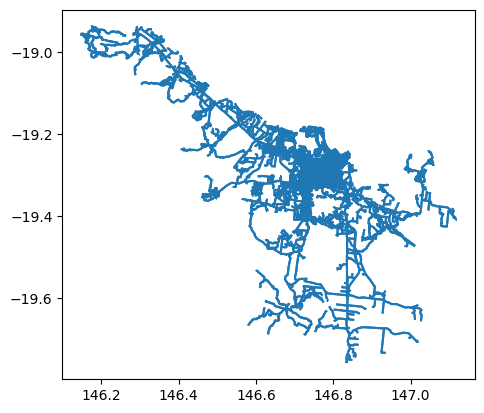

In [13]:
gdf_streets = gpd.read_file('Townsville_POIs_streets.csv',GEOM_POSSIBLE_NAMES="geometry",
                            KEEP_GEOM_COLUMNS="NO", crs='EPSG:4326')
gdf_streets=gdf_streets.set_crs(epsg=4326, allow_override=True)
gdf_streets.plot()

Join both datasets `gdf_streets` and `gdf` to have a dataset of the road newtork with the associated zone unit each road belongs to

In [18]:
roads_region=gpd.sjoin(gdf_streets, gdf,how="inner",predicate='intersects')
roads_region.rename(columns={"index_right": new_ind},inplace=True)
pop_size = gdf.loc[roads_region[new_ind].unique()]

We generate home locations along the road network using the road network `roads_region` and the population of each zone unit `pop_size[pop]`

In [19]:
import time
execution_times = []
runs = 10
for i in range(runs):
    print(f"\nRun {i+1}/{runs}...")
    start_time = time.time()
    POI_houses = townsville.create_houses_streets(roads_region.copy(),pop_size=pop_size['pop'],crs='EPSG:4326')
    end_time = time.time()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"Run {i+1} completed in {elapsed_time:.4f} seconds.")

average_time = sum(execution_times) / len(execution_times)
shortest_time = min(execution_times)
longest_time = max(execution_times)

print("\n--- Timing Results ---")
print(f"Average computation time: {average_time:.4f} seconds")
print(f"Shortest computation time: {shortest_time:.4f} seconds")
print(f"Longest computation time: {longest_time:.4f} seconds")


Run 1/10...


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:356: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdk= gdf.groupby([index_col,'highway'])
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:383: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 1 completed in 5.7569 seconds.

Run 2/10...


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:356: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdk= gdf.groupby([index_col,'highway'])
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:383: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 2 completed in 5.9843 seconds.

Run 3/10...


...

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 8 completed in 6.2103 seconds.

Run 9/10...


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:356: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdk= gdf.groupby([index_col,'highway'])
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:383: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 9 completed in 5.4885 seconds.

Run 10/10...


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:356: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdk= gdf.groupby([index_col,'highway'])
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:383: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 10 completed in 6.2931 seconds.

--- Timing Results ---
Average computation time: 5.8088 seconds
Shortest computation time: 4.9373 seconds
Longest computation time: 6.3236 seconds


## Generating home locations within building geometries

To generate home locations along the road network, we need the geospatial information of the building shapes.
We can extract the road network from OSM using:

In [20]:
buildings=townsville.fetch_osm_buildings()

Obtaining buildings from OSM for {'city': 'Townsville', 'country': 'Australia'}. It can take a few minutes...
Filtering, cleaning and rearranging buildings for {'city': 'Townsville', 'country': 'Australia'}.
 It can take a few minutes...
OSM buildings obtained successfully. File saved as Townsville_POIs_buildings.csv


We read the obtained dataset

In [21]:
gdf_building = gpd.read_file('Townsville_POIs_buildings.csv',GEOM_POSSIBLE_NAMES="geometry", KEEP_GEOM_COLUMNS="NO", crs='EPSG:4326')
gdf_building=gdf_building.set_crs(epsg=4326, allow_override=True)

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver CSV does not support open option CRS
  return ogr_read(


We filter the dataset to obtain only buildings that can allocate homes

In [22]:
gdf_building['building']=gdf_building['building'].astype(str)
gdf_building=gdf_building[(gdf_building['building']=='yes') | (gdf_building['building']=='hotel')| (gdf_building['building']=='apartment')| (gdf_building['building']=='apartments')| (gdf_building['building']=='bungalow')| (gdf_building['building']=='cabin')| (gdf_building['building']=='dormitory')| (gdf_building['building']=='flats')| (gdf_building['building']=='house')|  (gdf_building['building']=='residential')| (gdf_building['building']=='boathouse')| (gdf_building['building']=='allotment_house')| (gdf_building['building']=='terrace')| (gdf_building['building']=='transformer_house')| (gdf_building['building']=='summer_house')| (gdf_building['building']=='houseboat')| (gdf_building['building']=='terrace')]
gdf_building=gdf_building[['building','geometry']]

Join both datasets `gdf_building` and `gdf` to have a dataset of the road newtork with the associated zone unit each road belongs to

In [23]:
buildings_region=gpd.sjoin(gdf_building, gdf,how="left",predicate='within')
buildings_region.rename(columns={"index_right": new_ind},inplace=True)
buildings_region=buildings_region.dropna(subset=new_ind)
pop_size = gdf.loc[buildings_region[new_ind].unique()]

Generate the locations within the buildings. The generation is based on the types of buildings in **building** column of `buildings_region`

In [24]:
import time
execution_times = []
building_type_column = 'building'
runs = 10
for i in range(runs):
    print(f"\nRun {i+1}/{runs}...")
    start_time = time.time()
    POI_houses = townsville.create_houses_buildings(buildings_region.copy(),pop_size=pop_size['pop'],index_column=new_ind,building_column=building_type_column,crs='EPSG:4326')
    end_time = time.time()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"Run {i+1} completed in {elapsed_time:.4f} seconds.")

average_time = sum(execution_times) / len(execution_times)
shortest_time = min(execution_times)
longest_time = max(execution_times)

print("\n--- Timing Results ---")
print(f"Average computation time: {average_time:.4f} seconds")
print(f"Shortest computation time: {shortest_time:.4f} seconds")
print(f"Longest computation time: {longest_time:.4f} seconds")


Run 1/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 1 completed in 11.4894 seconds.

Run 2/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 2 completed in 10.8638 seconds.

Run 3/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 3 completed in 10.8081 seconds.

Run 4/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 4 completed in 11.1266 seconds.

Run 5/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 5 completed in 12.3069 seconds.

Run 6/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk